Best Parameters from Grid Search:
{'C': 1, 'gamma': 0.001}

=== SVM (RBF) — Test Metrics ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix:
[[36  0]
 [ 0 36]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        36

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



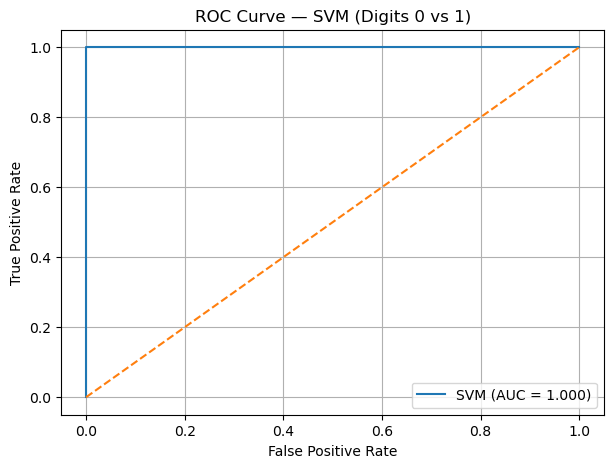

In [1]:
# =========================
# EXPERIMENT 4B — SVM
# =========================

# 1) Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# 2) Load Dataset

digits = load_digits()

X = digits.data
y = digits.target


# 3) Select only two classes: Digit 0 and Digit 1

mask = (y == 0) | (y == 1)

X = X[mask]
y = y[mask]


# 4) Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# 5) Standardize Features

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


# 6) Define SVM Model

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)


# 7) Hyperparameter Tuning

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_sc, y_train)

print("Best Parameters from Grid Search:")
print(grid.best_params_)

best_svm = grid.best_estimator_


# 8) Train Final Model and Predict

best_svm.fit(X_train_sc, y_train)

y_pred = best_svm.predict(X_test_sc)

y_prob = best_svm.predict_proba(X_test_sc)[:, 1]


# 9) Evaluation

acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)


print("\n=== SVM (RBF) — Test Metrics ===")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# 10) Plot ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — SVM (Digits 0 vs 1)")

plt.legend()
plt.grid(True)

plt.show()